# Controlled (in-distribution) USE re-split experiment -- multi-seed results

**Protocol A**: fixed 70/15/15 *author-disjoint* train/val/test split of the 5,547-record USE-only
cache (963 human `use` + 4,584 `use_rewrite`), varying the split seed across 5 runs (seeds 0-4).
The published 589/829 split is **not** pinned to seed 0.

For each seed all **14 models** are retrained from scratch on that seed's TRAIN and scored on its
held-out TEST:

- 7 classical backends: `xgboost, random_forest, logreg, svm, mlp, hist_gbm, gradient_boosting`
- 4 neural fusion heads: `concat, mlp, attention, gating`
- 3 single-modality random forests: `nela, style, trace`

The strict-FPR <= 1% threshold is calibrated on **VAL only** (positive class = AI = label 1) and
applied to TEST. This notebook loads the per-seed result JSONs produced by
`scripts/controlled_resplit/run_seed.py`, builds per-model mean +/- std tables, bootstrap 95% CIs
on the top models, a McNemar paired test between the top 2, and renders/saves all plots.

Re-run top-to-bottom after `run_seed.py` has written `models/ready_models_resplit/results/seed*_results.json`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
while REPO_ROOT.name and not (REPO_ROOT / "training").is_dir():
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "models" / "ready_models_resplit" / "results"
PLOTS_DIR = RESULTS_DIR  # PNGs saved alongside the json
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
STRICT_FPR = 0.01

seed_files = sorted(RESULTS_DIR.glob("seed*_results.json"))
print(f"REPO_ROOT  = {REPO_ROOT}")
print(f"found {len(seed_files)} seed result files:")
for f in seed_files:
    print("  ", f.name)
assert seed_files, "No seed results found. Run: python -m scripts.controlled_resplit.run_seed --seed 0 1 2 3 4"

REPO_ROOT  = C:\Users\Dimin\Documents\Hanyang\Smart Mobile Computing (AI-driven approaches)\repos\modern-AI-detection-trends-comparison
found 5 seed result files:
   seed0_results.json
   seed1_results.json
   seed2_results.json
   seed3_results.json
   seed4_results.json


## 1. Load per-seed results into a long dataframe

One row per (seed, model). Per-record arrays (`test_y_true`, `test_p_ai`, `test_pred_05`) are kept in
a side dict keyed by (seed, model) for the bootstrap + McNemar steps.

In [2]:
rows = []
preds = {}  # (seed, model) -> dict of per-record arrays
seed_meta = {}
for f in seed_files:
    blob = json.loads(f.read_text())
    seed = blob["seed"]
    seed_meta[seed] = {"n_val": blob["n_val"], "n_test": blob["n_test"]}
    for r in blob["results"]:
        rows.append({
            "seed": seed,
            "model": r["model"],
            "kind": r["kind"],
            "acc": r["test_acc"],
            "macro_f1": r["test_macro_f1"],
            "roc_auc": r["test_roc_auc"],
            "tpr_strict": r["test_tpr_at_strict_fpr"],
            "fpr_strict": r["test_fpr_at_strict_fpr"],
            "strict_thr": r["strict_fpr_threshold"],
        })
        preds[(seed, r["model"])] = {
            "y_true": np.asarray(r["test_y_true"], dtype=int),
            "p_ai": np.asarray(r["test_p_ai"], dtype=float),
            "pred_05": np.asarray(r["test_pred_05"], dtype=int),
        }

df = pd.DataFrame(rows)
print("seeds:", sorted(df.seed.unique()), "  models:", df.model.nunique(), "  rows:", len(df))
print("per-seed split sizes:", seed_meta)
df.head()

seeds: [0, 1, 2, 3, 4]   models: 14   rows: 70
per-seed split sizes: {0: {'n_val': 819, 'n_test': 859}, 1: {'n_val': 820, 'n_test': 828}, 2: {'n_val': 804, 'n_test': 840}, 3: {'n_val': 863, 'n_test': 835}, 4: {'n_val': 828, 'n_test': 813}}


,seed,model,kind,acc,macro_f1,roc_auc,tpr_strict,fpr_strict,strict_thr
0,0,clf_xgboost,classical,0.996508,0.993926,0.999962,0.997183,0.006711,0.260605
1,0,clf_random_forest,classical,0.995343,0.991880,0.999943,0.995775,0.006711,0.675000
2,0,clf_logreg,classical,0.996508,0.993958,0.999953,0.995775,0.000000,0.540594
3,0,clf_svm,classical,0.994179,0.989823,0.999887,0.992958,0.000000,0.812209
4,0,clf_mlp,classical,0.991851,0.985902,0.999877,0.991549,0.006711,0.718031


## 2. Per-model summary table (mean +/- std across seeds)

The headline controlled-set table: each model's TEST metrics averaged over the 5 seeds, with the
across-seed standard deviation as the variance estimate.

In [3]:
METRICS = ["acc", "macro_f1", "roc_auc", "tpr_strict"]
agg = df.groupby(["model", "kind"])[METRICS].agg(["mean", "std"]).reset_index()
agg.columns = ["model", "kind"] + [f"{m}_{s}" for m in METRICS for s in ("mean", "std")]
agg = agg.sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)

def fmt(mean, std):
    return f"{mean:.4f} +/- {std:.4f}"

summary = pd.DataFrame({
    "model": agg["model"],
    "kind": agg["kind"],
    "macro_F1": [fmt(m, s) for m, s in zip(agg.macro_f1_mean, agg.macro_f1_std)],
    "ROC_AUC": [fmt(m, s) for m, s in zip(agg.roc_auc_mean, agg.roc_auc_std)],
    "acc": [fmt(m, s) for m, s in zip(agg.acc_mean, agg.acc_std)],
    "TPR@FPR<=1%": [fmt(m, s) for m, s in zip(agg.tpr_strict_mean, agg.tpr_strict_std)],
})
summary

,model,kind,macro_F1,ROC_AUC,acc,TPR@FPR<=1%
0,clf_logreg,classical,0.9979 +/- 0.0025,1.0000 +/- 0.0000,0.9988 +/- 0.0014,0.9992 +/- 0.0019
1,clf_hist_gbm,classical,0.9937 +/- 0.0033,0.9998 +/- 0.0002,0.9964 +/- 0.0019,0.9886 +/- 0.0124
2,fusion_concat,neural,0.9934 +/- 0.0063,0.9999 +/- 0.0002,0.9962 +/- 0.0037,0.9953 +/- 0.0030
3,fusion_mlp,neural,0.9934 +/- 0.0063,0.9999 +/- 0.0002,0.9962 +/- 0.0037,0.9953 +/- 0.0030
4,fusion_gating,neural,0.9934 +/- 0.0061,0.9999 +/- 0.0002,0.9962 +/- 0.0035,0.9986 +/- 0.0020
5,clf_svm,classical,0.9933 +/- 0.0026,0.9999 +/- 0.0001,0.9962 +/- 0.0015,0.9962 +/- 0.0026
6,clf_mlp,classical,0.9917 +/- 0.0037,0.9999 +/- 0.0000,0.9952 +/- 0.0021,0.9936 +/- 0.0026
7,clf_xgboost,classical,0.9913 +/- 0.0027,0.9997 +/- 0.0004,0.9950 +/- 0.0016,0.9862 +/- 0.0129
8,rf_nela,single_modality,0.9908 +/- 0.0025,0.9998 +/- 0.0003,0.9947 +/- 0.0014,0.9789 +/- 0.0181
9,clf_gradient_boosting,classical,0.9904 +/- 0.0038,0.9997 +/- 0.0003,0.9945 +/- 0.0022,0.9781 +/- 0.0195


In [4]:
# Persist the summary table as CSV for the text relay
agg.to_csv(RESULTS_DIR / "summary_mean_std.csv", index=False)
summary.to_csv(RESULTS_DIR / "summary_table.csv", index=False)
print("wrote", RESULTS_DIR / "summary_table.csv")

wrote C:\Users\Dimin\Documents\Hanyang\Smart Mobile Computing (AI-driven approaches)\repos\modern-AI-detection-trends-comparison\models\ready_models_resplit\results\summary_table.csv


## 3. Bootstrap 95% CIs on the top models (pooled TEST records across seeds)

For the top models by mean macro-F1 we bootstrap the pooled per-record TEST predictions across all
seeds (resampling records with replacement, 2000 draws) to get a 95% CI on macro-F1, ROC-AUC and
TPR@strict-FPR. Pooling across seeds gives a single distribution per model that already absorbs the
seed-to-seed variation in which records land in TEST.

In [5]:
from sklearn.metrics import f1_score, roc_auc_score

def pooled_records(model):
    yt = np.concatenate([preds[(s, model)]["y_true"] for s in sorted(df.seed.unique())])
    pa = np.concatenate([preds[(s, model)]["p_ai"] for s in sorted(df.seed.unique())])
    return yt, pa

def tpr_at_strict(yt, pa, max_fpr=STRICT_FPR):
    hs = np.sort(pa[yt == 0])
    if hs.size == 0:
        return np.nan
    allowed = int(np.floor(max_fpr * hs.size))
    thr = hs[0] if allowed >= hs.size else hs[hs.size - allowed - 1] + 1e-12
    ai = yt == 1
    return float((pa[ai] >= thr).mean()) if ai.any() else np.nan

def bootstrap_ci(model, n_boot=2000, seed=0):
    yt, pa = pooled_records(model)
    rng = np.random.default_rng(seed)
    n = len(yt)
    f1s, aucs, tprs = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        ytb, pab = yt[idx], pa[idx]
        if len(np.unique(ytb)) < 2:
            continue
        f1s.append(f1_score(ytb, (pab >= 0.5).astype(int), average="macro", zero_division=0))
        aucs.append(roc_auc_score(ytb, pab))
        tprs.append(tpr_at_strict(ytb, pab))
    def ci(a):
        a = np.asarray(a)
        return float(np.mean(a)), float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))
    return {"macro_f1": ci(f1s), "roc_auc": ci(aucs), "tpr_strict": ci(tprs)}

TOP_K = 5
top_models = list(agg.model.head(TOP_K))
ci_rows = []
for m in top_models:
    c = bootstrap_ci(m)
    ci_rows.append({
        "model": m,
        "macro_F1 [95% CI]": f"{c['macro_f1'][0]:.4f} [{c['macro_f1'][1]:.4f}, {c['macro_f1'][2]:.4f}]",
        "ROC_AUC [95% CI]": f"{c['roc_auc'][0]:.4f} [{c['roc_auc'][1]:.4f}, {c['roc_auc'][2]:.4f}]",
        "TPR@FPR<=1% [95% CI]": f"{c['tpr_strict'][0]:.4f} [{c['tpr_strict'][1]:.4f}, {c['tpr_strict'][2]:.4f}]",
    })
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(RESULTS_DIR / "top_models_bootstrap_ci.csv", index=False)
ci_store = {m: bootstrap_ci(m) for m in top_models}
ci_df

,model,macro_F1 [95% CI],ROC_AUC [95% CI],TPR@FPR<=1% [95% CI]
0,clf_logreg,"0.9979 [0.9958, 0.9996]","1.0000 [1.0000, 1.0000]","0.9993 [0.9980, 1.0000]"
1,clf_hist_gbm,"0.9937 [0.9904, 0.9966]","0.9998 [0.9996, 1.0000]","0.9970 [0.9925, 0.9991]"
2,fusion_concat,"0.9933 [0.9898, 0.9963]","0.9998 [0.9995, 1.0000]","0.9974 [0.9948, 0.9991]"
3,fusion_mlp,"0.9933 [0.9898, 0.9963]","0.9998 [0.9995, 1.0000]","0.9974 [0.9948, 0.9991]"
4,fusion_gating,"0.9933 [0.9898, 0.9964]","0.9999 [0.9997, 1.0000]","0.9982 [0.9948, 0.9997]"


## 4. McNemar paired test between the top 2 models

Per seed we build the 2x2 discordance table on TEST predictions @0.5 (records where exactly one of
the top-2 models is correct), then pool the discordant counts across seeds and run an exact-binomial
McNemar test. A non-significant result (p > 0.05) means the two models are statistically
indistinguishable on the controlled set.

In [6]:
from scipy.stats import binomtest

m_a, m_b = top_models[0], top_models[1]
b_total = c_total = 0  # b: A right & B wrong ; c: A wrong & B right
for s in sorted(df.seed.unique()):
    yt = preds[(s, m_a)]["y_true"]
    a_correct = preds[(s, m_a)]["pred_05"] == yt
    b_correct = preds[(s, m_b)]["pred_05"] == yt
    b_total += int(np.sum(a_correct & ~b_correct))
    c_total += int(np.sum(~a_correct & b_correct))

n_disc = b_total + c_total
if n_disc == 0:
    p_value = 1.0
    print(f"McNemar {m_a} vs {m_b}: ZERO discordant records across all seeds -> identical TEST predictions, p = 1.0")
else:
    p_value = binomtest(b_total, n_disc, 0.5).pvalue
    print(f"McNemar {m_a} vs {m_b}:")
    print(f"  discordant: {m_a}>only={b_total}  {m_b}>only={c_total}  (total {n_disc})")
    print(f"  exact binomial p-value = {p_value:.4f}")
print("  ->", "SIGNIFICANT difference" if p_value < 0.05 else "NOT significant (indistinguishable on the controlled set)")

mcnemar_result = {"model_a": m_a, "model_b": m_b, "b": b_total, "c": c_total,
                  "n_discordant": n_disc, "p_value": p_value,
                  "significant": bool(p_value < 0.05)}
(RESULTS_DIR / "mcnemar_top2.json").write_text(json.dumps(mcnemar_result, indent=2))
mcnemar_result

McNemar clf_logreg vs clf_hist_gbm:
  discordant: clf_logreg>only=13  clf_hist_gbm>only=3  (total 16)
  exact binomial p-value = 0.0213
  -> SIGNIFICANT difference


{'model_a': 'clf_logreg',
 'model_b': 'clf_hist_gbm',
 'b': 13,
 'c': 3,
 'n_discordant': 16,
 'p_value': 0.021270751953125,
 'significant': True}

## 5. Plots

(a) ROC-AUC mean +/- std, (b) macro-F1@0.5 mean +/- std, (c) TPR@strict-FPR<=1% mean +/- std,
(d) bootstrap 95% CI ranges of the top models (saturation/overlap view).

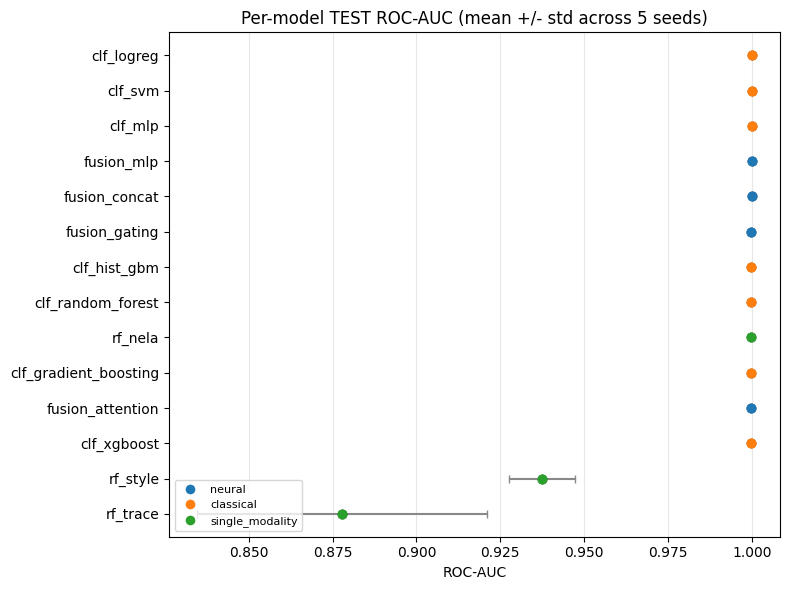

saved C:\Users\Dimin\Documents\Hanyang\Smart Mobile Computing (AI-driven approaches)\repos\modern-AI-detection-trends-comparison\models\ready_models_resplit\results\plot_roc_auc.png


In [7]:
def point_std_plot(metric, title, xlabel, fname):
    sub = agg.sort_values(f"{metric}_mean", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    y = np.arange(len(sub))
    colors = {"neural": "#1f77b4", "classical": "#ff7f0e", "single_modality": "#2ca02c"}
    ax.errorbar(sub[f"{metric}_mean"], y, xerr=sub[f"{metric}_std"].fillna(0),
                fmt="o", capsize=3, color="#333333", ecolor="#888888", zorder=3)
    for yi, (_, r) in zip(y, sub.iterrows()):
        ax.scatter(r[f"{metric}_mean"], yi, color=colors.get(r["kind"], "gray"), zorder=4, s=40)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["model"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=k)
               for k, c in colors.items()]
    ax.legend(handles=handles, loc="lower left", fontsize=8)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / fname, dpi=150)
    plt.show()
    print("saved", PLOTS_DIR / fname)

point_std_plot("roc_auc", "Per-model TEST ROC-AUC (mean +/- std across 5 seeds)",
               "ROC-AUC", "plot_roc_auc.png")

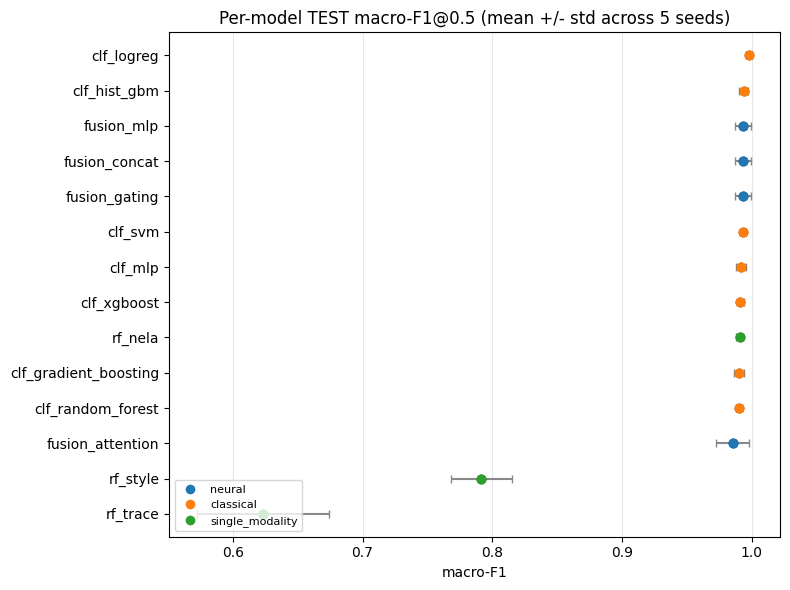

saved C:\Users\Dimin\Documents\Hanyang\Smart Mobile Computing (AI-driven approaches)\repos\modern-AI-detection-trends-comparison\models\ready_models_resplit\results\plot_macro_f1.png


In [8]:
point_std_plot("macro_f1", "Per-model TEST macro-F1@0.5 (mean +/- std across 5 seeds)",
               "macro-F1", "plot_macro_f1.png")

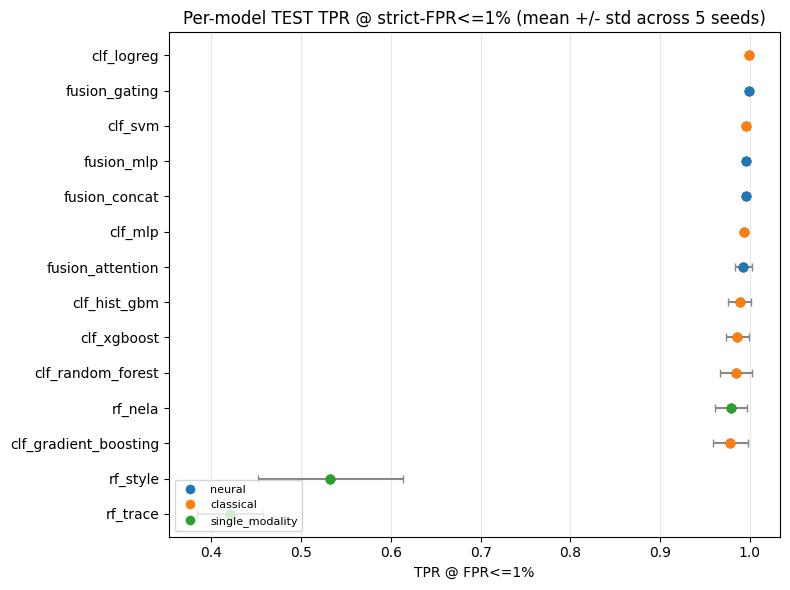

saved C:\Users\Dimin\Documents\Hanyang\Smart Mobile Computing (AI-driven approaches)\repos\modern-AI-detection-trends-comparison\models\ready_models_resplit\results\plot_tpr_strict.png


In [9]:
point_std_plot("tpr_strict", "Per-model TEST TPR @ strict-FPR<=1% (mean +/- std across 5 seeds)",
               "TPR @ FPR<=1%", "plot_tpr_strict.png")

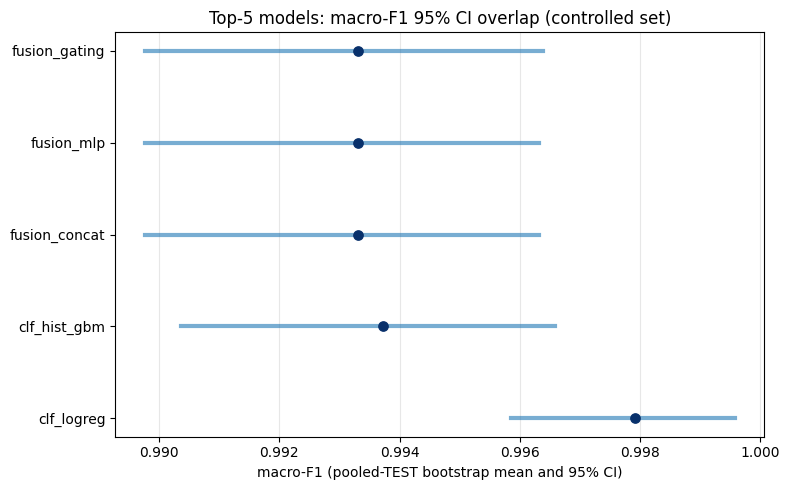

saved C:\Users\Dimin\Documents\Hanyang\Smart Mobile Computing (AI-driven approaches)\repos\modern-AI-detection-trends-comparison\models\ready_models_resplit\results\plot_top_models_ci_overlap.png


In [10]:
# (d) bootstrap CI ranges of the top models -- the saturation/overlap view
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(top_models))
for yi, m in zip(y, top_models):
    mean, lo, hi = ci_store[m]["macro_f1"]
    ax.plot([lo, hi], [yi, yi], color="#1f77b4", lw=3, alpha=0.6, zorder=2)
    ax.scatter([mean], [yi], color="#08306b", zorder=3, s=45)
ax.set_yticks(y)
ax.set_yticklabels(top_models)
ax.set_xlabel("macro-F1 (pooled-TEST bootstrap mean and 95% CI)")
ax.set_title(f"Top-{len(top_models)} models: macro-F1 95% CI overlap (controlled set)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "plot_top_models_ci_overlap.png", dpi=150)
plt.show()
print("saved", PLOTS_DIR / "plot_top_models_ci_overlap.png")

## 6. Text summary for relay

Auto-generated paragraph stating the per-model variance, whether the top model is statistically
distinguishable, and the in-distribution vs OOD recommendation.

In [11]:
best = agg.iloc[0]
f1_spread = agg.macro_f1_mean.max() - agg.macro_f1_mean.min()
max_std = agg.macro_f1_std.max()
auc_at_ceiling = int((agg.roc_auc_mean >= 0.999).sum())
f1_at_ceiling = int((agg.macro_f1_mean >= 0.987).sum())

lines = []
lines.append(f"Controlled (in-distribution) USE set, protocol A, 5 seeds, {df.model.nunique()} models.")
lines.append(f"Top model by mean macro-F1: {best['model']} ({best['kind']}) = "
             f"{best.macro_f1_mean:.4f} +/- {best.macro_f1_std:.4f}; "
             f"ROC-AUC {best.roc_auc_mean:.4f} +/- {best.roc_auc_std:.4f}; "
             f"TPR@FPR<=1% {best.tpr_strict_mean:.4f} +/- {best.tpr_strict_std:.4f}.")
lines.append(f"Macro-F1 spread across all models = {f1_spread:.4f}; max across-seed std = {max_std:.4f}.")
lines.append(f"{f1_at_ceiling}/{len(agg)} models at macro-F1 >= 0.987; "
             f"{auc_at_ceiling}/{len(agg)} models at ROC-AUC >= 0.999.")
if mcnemar_result['n_discordant'] == 0:
    lines.append(f"McNemar {m_a} vs {m_b}: identical TEST predictions (0 discordant) -> not distinguishable.")
else:
    lines.append(f"McNemar {m_a} vs {m_b}: p = {mcnemar_result['p_value']:.4f} -> "
                 f"{'SIGNIFICANT' if mcnemar_result['significant'] else 'NOT significant'}.")
verdict = ("Models are tied at the ceiling with overlapping CIs and a non-significant McNemar: "
           "the in-distribution set CANNOT support a defensible best-model claim; ranking must "
           "defer to the OOD arxiv/humanized splits."
           if (not mcnemar_result['significant'] and f1_spread < 0.02)
           else "At least one model is separable on the controlled set; see the table/CIs above.")
lines.append("RECOMMENDATION: " + verdict)
summary_text = "\n".join(lines)
print(summary_text)
(RESULTS_DIR / "text_summary.txt").write_text(summary_text, encoding="utf-8")

Controlled (in-distribution) USE set, protocol A, 5 seeds, 14 models.
Top model by mean macro-F1: clf_logreg (classical) = 0.9979 +/- 0.0025; ROC-AUC 1.0000 +/- 0.0000; TPR@FPR<=1% 0.9992 +/- 0.0019.
Macro-F1 spread across all models = 0.3749; max across-seed std = 0.0509.
11/14 models at macro-F1 >= 0.987; 12/14 models at ROC-AUC >= 0.999.
McNemar clf_logreg vs clf_hist_gbm: p = 0.0213 -> SIGNIFICANT.
RECOMMENDATION: At least one model is separable on the controlled set; see the table/CIs above.


501

## 7. Per-model extractor importance (NELA / StyleDecipher / TRACE)

Internal importance of each extractor block per classifier, recomputed from the resplit checkpoints
and averaged over the 5 seeds. For linear `clf_logreg` this is the summed `|coefficient|` per block;
for tree ensembles it is summed impurity importance. Models exposing no importance (RBF-`clf_svm`,
sklearn `clf_mlp`) are omitted; the neural fusion heads expose only *permutation* importance (see
`models/analysis.ipynb`).

**Caveat — read alongside the other lenses, not alone.** `clf_logreg`'s ~49% NELA / 39% TRACE / 12%
Style split is inflated by block *dimensionality* (TRACE = 128 dims vs NELA 87, Style 10): summing
many small coefficients enlarges TRACE's share. The tree-impurity view here (NELA 80-99%), the
Cohen's *d* analysis (17 NELA dims >1 sigma, 0 TRACE dims), and the standalone result (`rf_trace`
macro-F1 only ~0.62) all agree that NELA dominates. The linear-coefficient split is **not** evidence
that TRACE carries ~40% of the real signal.

,model,nela %,nela std,style %,style std,trace %,trace std
0,clf_random_forest_nela,100.0,0.0,NaN,NaN,NaN,NaN
1,clf_gradient_boosting,98.5,0.3,0.3,0.1,1.2,0.4
2,clf_random_forest,90.4,0.4,1.5,0.1,8.2,0.4
3,clf_xgboost,80.5,3.5,3.1,1.2,16.4,3.4
4,clf_logreg,49.2,2.0,11.5,0.6,39.3,2.5
5,clf_random_forest_style,NaN,NaN,100.0,0.0,NaN,NaN
6,clf_random_forest_trace,NaN,NaN,NaN,NaN,100.0,0.0


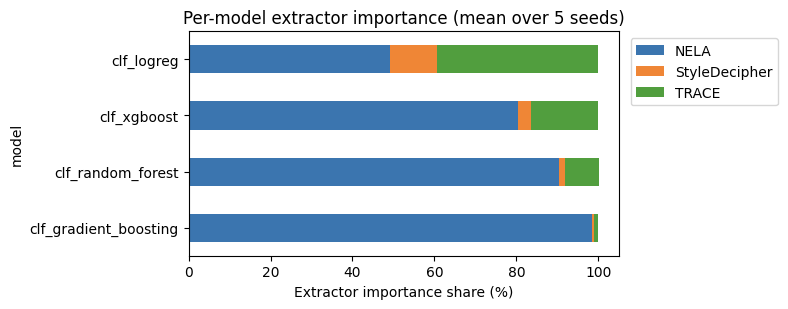

saved C:\Users\Dimin\Documents\Hanyang\Smart Mobile Computing (AI-driven approaches)\repos\modern-AI-detection-trends-comparison\models\ready_models_resplit\results\plot_extractor_importance.png


In [12]:
# === Per-model extractor importance (NELA / StyleDecipher / TRACE), multi-seed ===
import sys
from collections import defaultdict

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from training import paths  # noqa: F401  (sys.path bootstrap for bare imports)
from training.classical import ClassicalClassifier, block_importances

CKPT = REPO_ROOT / "models" / "ready_models_resplit"
IMP_SEEDS = sorted(df.seed.unique())

per_model = defaultdict(lambda: {"nela": [], "style": [], "trace": []})
for seed in IMP_SEEDS:
    for jb in sorted((CKPT / f"seed{seed}").glob("*.joblib")):
        clf, payload = ClassicalClassifier.load(jb)
        imp = clf.feature_importances()          # |coef| for linear, impurity for trees
        if imp is None:                          # rbf-SVM / sklearn MLP expose none
            continue
        shares = block_importances(imp, payload["dims"])
        for blk in ("nela", "style", "trace"):
            if blk in shares:
                per_model[jb.stem][blk].append(shares[blk])

imp_rows = []
for name, blocks in per_model.items():
    row = {"model": name}
    for blk in ("nela", "style", "trace"):
        v = blocks[blk]
        row[f"{blk} %"] = round(100 * float(np.mean(v)), 1) if v else np.nan
        row[f"{blk} std"] = round(100 * float(np.std(v)), 1) if v else np.nan
    imp_rows.append(row)

imp_df = (pd.DataFrame(imp_rows)
          .sort_values("nela %", ascending=False, na_position="last")
          .reset_index(drop=True))
imp_df.to_csv(RESULTS_DIR / "extractor_importance.csv", index=False)
display(imp_df)

# stacked horizontal bar for the combined (3-block) models only
full = (imp_df.dropna(subset=["style %", "trace %"])
        .set_index("model")[["nela %", "style %", "trace %"]])
ax = full.plot(kind="barh", stacked=True, figsize=(8, 3.2),
               color=["#3b75af", "#ef8636", "#519e3e"])
ax.set_xlabel("Extractor importance share (%)")
ax.set_title("Per-model extractor importance (mean over 5 seeds)")
ax.legend(["NELA", "StyleDecipher", "TRACE"], bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_extractor_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved", RESULTS_DIR / "plot_extractor_importance.png")